In [103]:
#Loading Data:
#df stand for dataFrame
import pandas as pd
df = pd.read_csv('train_data.csv')

In [104]:
#check data
df.dtypes

Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

In [105]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,304.000000,304.000000,304.000000,295.000000,281.000000
mean,3583.828947,1220.645132,105.282895,342.101695,0.822064
std,1366.102888,1732.098606,28.696412,67.192306,0.383141
min,210.000000,0.000000,17.000000,12.000000,0.000000
25%,2651.000000,0.000000,90.000000,360.000000,1.000000
50%,3365.500000,953.000000,110.500000,360.000000,1.000000
75%,4284.250000,2045.000000,128.000000,360.000000,1.000000
max,9703.000000,20000.000000,150.000000,480.000000,1.000000


In [106]:
df.isna().sum()/100 #checking null values


Loan_ID              0.00
Gender               0.03
Married              0.00
Dependents           0.07
Education            0.00
Self_Employed        0.17
ApplicantIncome      0.00
CoapplicantIncome    0.00
LoanAmount           0.00
Loan_Amount_Term     0.09
Credit_History       0.23
Property_Area        0.00
Loan_Status          0.00
dtype: float64

In [107]:
from sklearn.preprocessing import LabelEncoder
#filling nulls
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].median())
#cleaning 3+ and nulls
df['Dependents'] = df['Dependents'].astype(str).str.replace('3+', '3').str.replace('nan', '0')
df['Dependents'] = pd.to_numeric(df['Dependents'], errors='coerce').fillna(0).astype(int)


In [108]:
# Encode categorical variables into numeric values
le = LabelEncoder()
categ_cols = ['Loan_ID','Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
#added Load_ID to the catag_cols since it is a string could be removed since we will not use it
for col in categ_cols:
    df[col] = le.fit_transform(df[col].astype(str)) # Added astype(str) to avoid errors with mixed types

In [109]:
#now lets check the data
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
299,52,1,1,1,0,0,3052,1030.0,100.0,360.0,1.0,2,1
300,77,1,1,0,0,0,3497,1964.0,116.0,360.0,1.0,0,1
301,213,1,1,0,0,0,2666,4300.0,121.0,360.0,1.0,0,1
302,281,1,1,0,0,0,2785,2016.0,110.0,360.0,1.0,0,1
303,74,1,0,0,0,0,2237,0.0,63.0,480.0,0.0,1,0


In [110]:
df.describe()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,304.00000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000,304.000000
mean,151.50000,0.782895,0.605263,0.661184,0.269737,0.082237,3583.828947,1220.645132,105.282895,342.631579,0.835526,1.036184,0.707237
std,87.90146,0.412955,0.489600,0.978485,0.444555,0.275178,1366.102888,1732.098606,28.696412,66.256595,0.371316,0.780543,0.455781
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,210.000000,0.000000,17.000000,12.000000,0.000000,0.000000,0.000000
25%,75.75000,1.000000,0.000000,0.000000,0.000000,0.000000,2651.000000,0.000000,90.000000,360.000000,1.000000,0.000000,0.000000
50%,151.50000,1.000000,1.000000,0.000000,0.000000,0.000000,3365.500000,953.000000,110.500000,360.000000,1.000000,1.000000,1.000000
75%,227.25000,1.000000,1.000000,1.000000,1.000000,0.000000,4284.250000,2045.000000,128.000000,360.000000,1.000000,2.000000,1.000000
max,303.00000,1.000000,1.000000,3.000000,1.000000,1.000000,9703.000000,20000.000000,150.000000,480.000000,1.000000,2.000000,1.000000


In [111]:
df = df[df['Gender'] != 2]

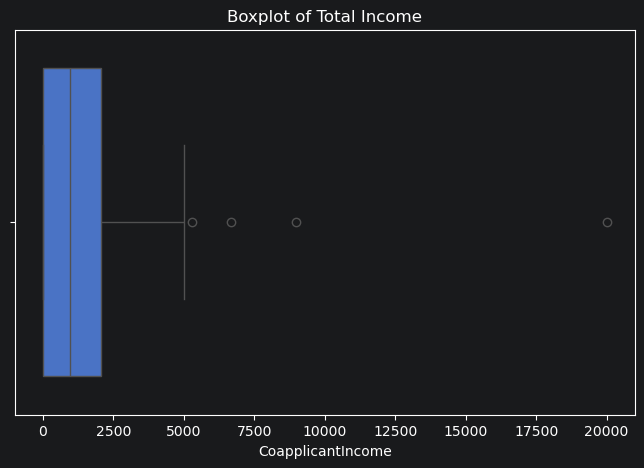

In [112]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check for outliers
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['CoapplicantIncome'])
plt.title('Boxplot of Total Income')
plt.show()

In [113]:
import numpy as np

In [114]:
# Squashing outliers using Log Transformation
df_transfromed = df[['Gender','Married','Dependents','Education','Self_Employed','Credit_History']].copy()
cols= ['ApplicantIncome', 'CoapplicantIncome', 'Loan_Amount_Term','LoanAmount']
for col in cols:
    df_transfromed[col+'_Log'] = np.log1p(df[col])
    #used log1p since there is data with the value 0 which does not have a log (I had a runtime error)


In [115]:
#now that we shrunk the data to get rid of outliar we will scale it

In [116]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
df_scaled = scaler.fit_transform(df_transfromed)

In [117]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
X = df_scaled  # all columns except target
y = df['Loan_Status']                # the binary target (0/1)
# Split into training and test sets (e.g., 80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y   # stratify for imbalanced classes
)#I wrote this line using AI I should change it later
#Man I wrote this whole note using AI i need to change it

# Create & train logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluate
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.918

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.72      0.84        18
           1       0.90      1.00      0.95        43

    accuracy                           0.92        61
   macro avg       0.95      0.86      0.89        61
weighted avg       0.93      0.92      0.91        61

Confusion Matrix:
[[13  5]
 [ 0 43]]


In [118]:
#now Lets test our model
test = pd.read_csv('./test_data.csv')
#Now lets prepocces our test data
test['Dependents'] = test['Dependents'].fillna(test['Dependents'].mode()[0])
test['Gender'] = test['Gender'].fillna(test['Gender'].mode()[0])
test['Self_Employed'] = test['Self_Employed'].fillna(test['Self_Employed'].mode()[0])
test['Loan_Amount_Term'] = test['Loan_Amount_Term'].fillna(test['Loan_Amount_Term'].median())
test['Credit_History'] = test['Credit_History'].fillna(test['Credit_History'].median())
test['Dependents'] = test['Dependents'].astype(str).str.replace('3+', '3').str.replace('nan', '0')
test['Dependents'] = pd.to_numeric(test['Dependents'], errors='coerce').fillna(0).astype(int)

#we will reuse the same scaler and encoder
for col in ['Loan_ID', 'Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']:
    test[col] = le.fit_transform(test[col].astype(str))
test = test[test['Gender'] != 2]

#Log transformation
test_transformed = test[['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Credit_History']].copy()
numeric_cols = ['ApplicantIncome', 'CoapplicantIncome', 'Loan_Amount_Term', 'LoanAmount']
for col in numeric_cols:
    test_transformed[col + '_Log'] = np.log1p(test[col])
X_test_scaled = scaler.transform(test_transformed)

# Now X_test_scaled is ready for model.predict()


In [119]:
#now lets test the model
y_tested_pred = model.predict(X_test_scaled)
y_test = test['Loan_Status']
# Evaluate
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print(f"Accuracy: {accuracy_score(y_test, y_tested_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_tested_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_tested_pred))

Accuracy: 0.8182

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.33      0.50        21
           1       0.80      1.00      0.89        56

    accuracy                           0.82        77
   macro avg       0.90      0.67      0.69        77
weighted avg       0.85      0.82      0.78        77

Confusion Matrix:
[[ 7 14]
 [ 0 56]]
